In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from ibrl.simulators import simulate
from ibrl.utils import construct_environment,dump_array,sample_action
from ibrl.environments import BernoulliBanditEnvironment
from ibrl.agents import InfraBayesianAgent, DiscreteBayesianAgent, EXP3Agent, ThompsonSamplingBernoulli
from ibrl.infrabayesian import AMeasure,Infradistribution,MultiBernoulliWorldModel

In [29]:
# Possible ranges for reward probabilities for each arm
range1 = (0.5,0.99)
range2 = (0.5,0.99)

# Convex hull of possible environments
corners = [
    [range1[0], range2[0]],
    [range1[1], range2[0]],
    [range1[0], range2[1]],
    [range1[1], range2[1]]
]

In [31]:
corners

[[0.5, 0.5], [0.99, 0.5], [0.5, 0.99], [0.99, 0.99]]

In [32]:
options = {
    "num_actions": 2,
    "num_steps":   501,
    "num_runs":    20,
    "seed":        42,
    "verbose":     0,
}
shared = dict(num_actions=2, seed=options["seed"] + 0x01234567, verbose=options["verbose"])

In [33]:
def ClassicalInfraBayesianAgent(num_actions: int, num_hypotheses: int = 5, **kwargs) -> InfraBayesianAgent:
    """Convenience: uniform grid of Bernoulli hypotheses, matching old default behaviour."""
    wm = MultiBernoulliWorldModel(num_arms=num_actions)
    grid = [np.array([1 - p, p]) for p in np.linspace(0.5, 0.99, num_hypotheses)]
    # Each arm gets the same N-point hypothesis grid independently.
    # A single a-measure with N components per arm gives correct independent
    # per-arm Bayesian inference — no joint enumeration needed.
    params = wm.make_params([grid] * num_actions)
    hypotheses = [Infradistribution([AMeasure(params)], world_model=wm)]
    return InfraBayesianAgent(num_actions=num_actions, hypotheses=hypotheses, exploration_prefix=None, **kwargs)

In [34]:
env2 = BernoulliBanditEnvironment(probs=[0.5,0.99], **options)
env3 = BernoulliBanditEnvironment(probs=[0.5,0.6], **options)
env4 = BernoulliBanditEnvironment(probs=[0.5,0.51], **options)
agent3 = ThompsonSamplingBernoulli(**shared)

gamma = np.sqrt(np.log(options["num_actions"])/options["num_actions"]/options["num_steps"])

agent4 = EXP3Agent(**shared, gamma=gamma)
wm = MultiBernoulliWorldModel(num_arms=2)
ib_agent = InfraBayesianAgent(hypotheses=[Infradistribution([
    AMeasure(wm.make_params(np.array([[1-p1,p1],[1-p2,p2]]))) for p1,p2 in corners
], wm)], **shared)

In [35]:
agents = {
    "Infrabayesian": ib_agent,
    "Thompson": agent3,
    "Exp3": agent4,
}
envs = {
    "p=[0.5, 0.99]": env2,
    "p=[0.5, 0.6]": env3,
    "p=[0.5, 0.51]": env4,
}

In [36]:
results_bandit = {
    env_name : {
        agent_name : simulate(env,agent,options,0x01234567,0x89abcdef)
        for agent_name,agent in agents.items()
    } for env_name,env in envs.items()
}

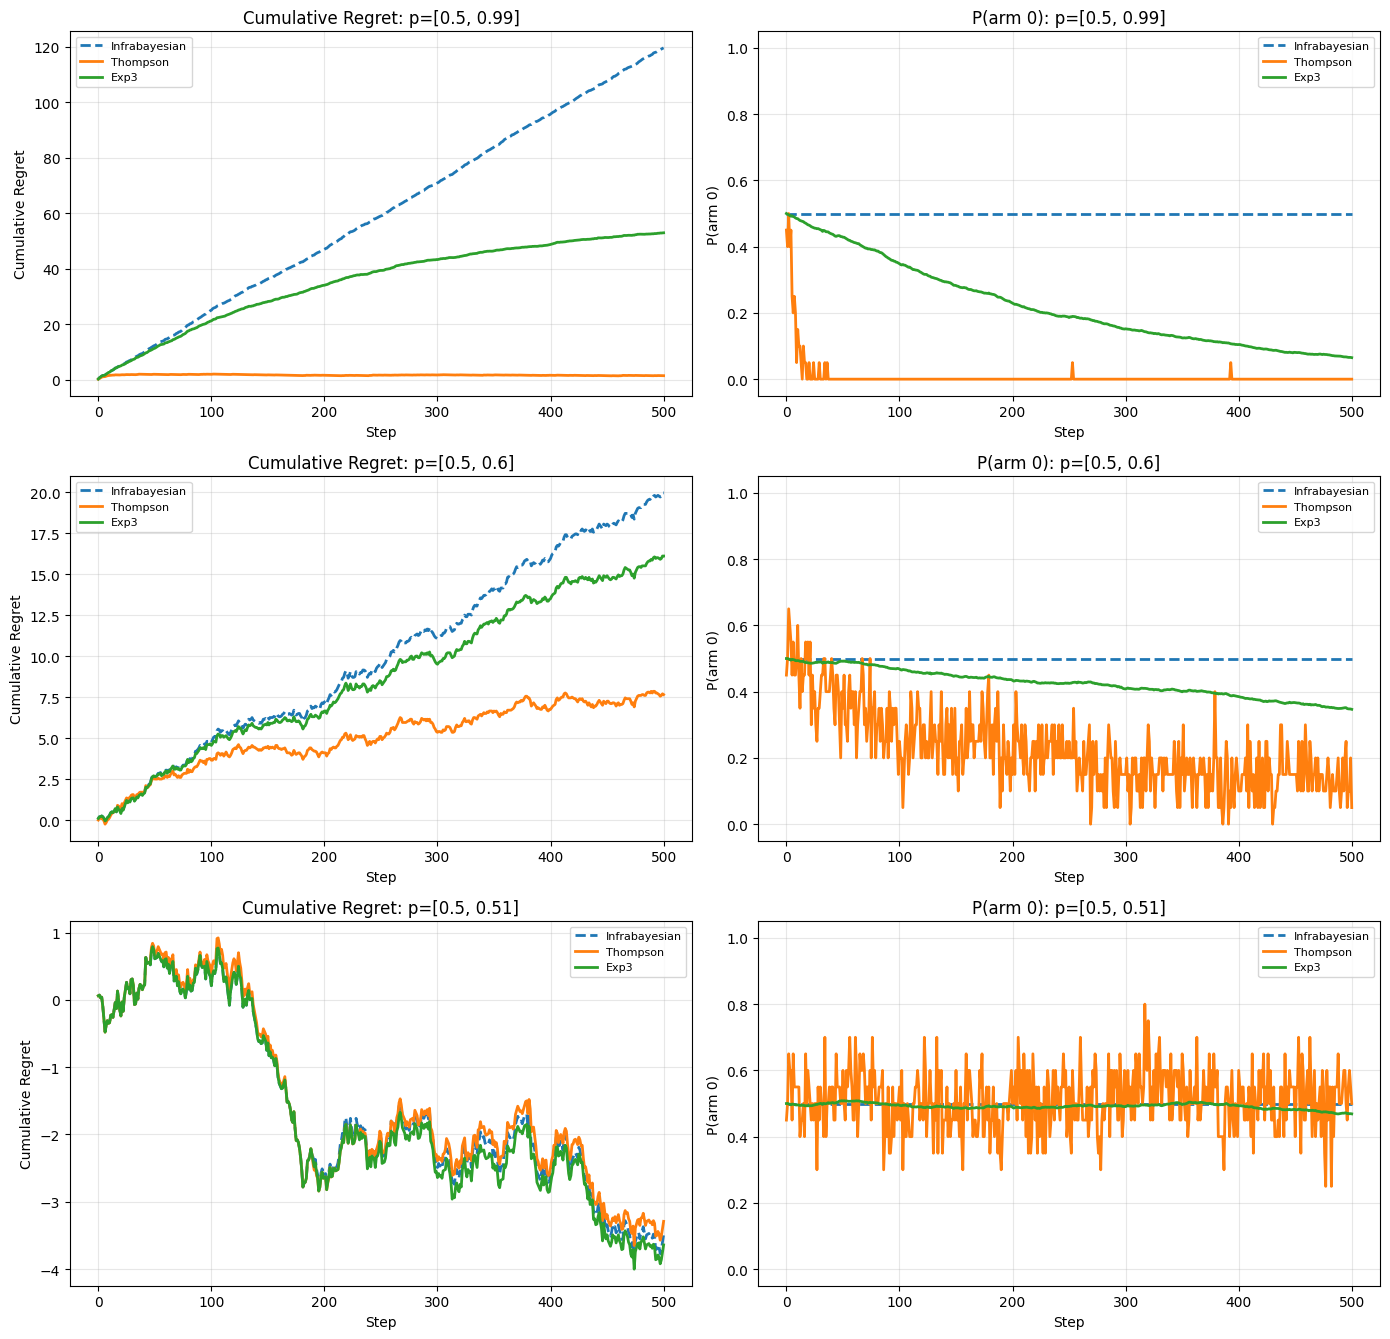

In [37]:
num_envs = len(results_bandit)
fig, axes = plt.subplots(num_envs, 2, figsize=(14, 4.5 * num_envs))

for i, (env_label, agent_results) in enumerate(results_bandit.items()):
    # Cumulative regret
    ax = axes[i, 0]
    for agent_name, res in agent_results.items():
        avg = res["average_reward"][0, :]
        regret = np.cumsum(res["optimal_reward"] - avg)
        ls = "--" if "Infrabayesian" in agent_name else "-"
        ax.plot(regret, label=agent_name, linewidth=2, ls=ls)
    ax.set_title(f"Cumulative Regret: {env_label}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Cumulative Regret")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Selection probabilities (arm 0)
    ax = axes[i, 1]
    for agent_name, res in agent_results.items():
        p0 = res["probabilities"][:, :, 0].mean(axis=0)
        ls = "--" if "Infrabayesian" in agent_name else "-"
        ax.plot(p0, label=f"{agent_name}", linewidth=2, ls=ls)
    ax.set_title(f"P(arm 0): {env_label}")
    ax.set_xlabel("Step")
    ax.set_ylabel("P(arm 0)")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()